In [1]:
import numpy as np
import few
import os
import sys
import pickle

dir_work = '/home/svu/e1498138/emri_search/work'
os.chdir(dir_work)
sys.path.insert(0, dir_work)

from GWfuncs_noise import GravWaveAnalysis, build_waveform_response
from loglike_timemax_noise import LogLike
import parismc
import cupy as cp

cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

use_gpu = True
tdi_gen = 1
dt = 10
T = 3/12
print(f"Using dt={dt}s, T={T}yr, TDI gen={tdi_gen}")

print('Building ResponseWrapper...')
waveform_response = build_waveform_response(T=T, dt=dt, use_gpu=True, tdi_gen=tdi_gen)

print('Building GravWaveAnalysis...')
gwf = GravWaveAnalysis(T=T, dt=dt, use_gpu=use_gpu, tdi_gen=tdi_gen)

# Source parameters
m1 = 1e6
m2 = 1e1
a = 0.7
p0 = 9
e0 = 0.4
xI0 = 1.0
dist = 5 #scale by 2-3x
qS = np.pi
phiS = 0.
qK = 0.
phiK = 0.
Phi_phi0 = 0.4
Phi_theta0 = 0.0
Phi_r0 = 0.5

params_star = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]
param_true = [np.log10(m1), np.log10(m2), a, p0, e0]

n_vals = np.arange(-1, 6)
ell = 2

print('Initializing LogLike...')
loglike_obj = LogLike(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=True,
    seed=42,
    verbose=False,
    ell=ell,
    n_vals=n_vals,
    M_mode=None,
)
print('LogLike initialized.')

data_snr = float(gwf.rhostat_timemax(loglike_obj.signal).get())
print(f'SNR (time-max): {data_snr:.4f}')


def log_density(params):
    params = np.asarray(params)
    log_likes = np.zeros(params.shape[0])
    for i in range(params.shape[0]):
        logm1, logm2, a, p0, e0 = params[i]
        try:
            loglike = loglike_obj(np.array([
                10**logm1, 10**logm2, a, p0, e0,
                xI0, dist, qS, phiS, qK, phiK,
                Phi_phi0, Phi_theta0, Phi_r0
            ]))
        except Exception:
            loglike = -np.inf
        log_likes[i] = loglike
    return log_likes


def prior_transform(u):
    logm1lim = [5.6, 6.4]
    logm2lim = [0.8, 1.3]
    alim = [0.3, 0.99]
    p0lim = [8.0, 11.0]
    e0lim = [0.2, 0.5]
    t = np.zeros_like(u)
    t[:, 0] = (logm1lim[1] - logm1lim[0]) * u[:, 0] + logm1lim[0]
    t[:, 1] = (logm2lim[1] - logm2lim[0]) * u[:, 1] + logm2lim[0]
    t[:, 2] = (alim[1] - alim[0]) * u[:, 2] + alim[0]
    t[:, 3] = (p0lim[1] - p0lim[0]) * u[:, 3] + p0lim[0]
    t[:, 4] = (e0lim[1] - e0lim[0]) * u[:, 4] + e0lim[0]
    return t


def inverse_prior_transform(params):
    logm1lim = [5.6, 6.4]
    logm2lim = [0.8, 1.3]
    alim = [0.3, 0.99]
    p0lim = [8.0, 11.0]
    e0lim = [0.2, 0.5]
    params = np.asarray(params)
    u = np.zeros_like(params)
    u[:, 0] = (params[:, 0] - logm1lim[0]) / (logm1lim[1] - logm1lim[0])
    u[:, 1] = (params[:, 1] - logm2lim[0]) / (logm2lim[1] - logm2lim[0])
    u[:, 2] = (params[:, 2] - alim[0]) / (alim[1] - alim[0])
    u[:, 3] = (params[:, 3] - p0lim[0]) / (p0lim[1] - p0lim[0])
    u[:, 4] = (params[:, 4] - e0lim[0]) / (e0lim[1] - e0lim[0])
    return u

Using dt=10s, T=0.25yr, TDI gen=1
Building ResponseWrapper...
Building GravWaveAnalysis...
Initializing LogLike...
LogLike initialized.
SNR (time-max): 1539.1741


In [2]:
dir_scratch = '/scratch/e1498138/'
savepath = dir_scratch + 'paris1_noise/int_3mth_noise_check_2'


In [3]:
sampler = parismc.Sampler.load_state(savepath+'/sampler_state.pkl')

In [4]:
samples, weights = sampler.get_samples_with_weights(flatten=True)

In [5]:
proc_pt = sampler.searched_points_list
proc_pt

[array([[0.5       , 0.4       , 0.57971014, 0.33333333, 0.66666667],
        [0.49999844, 0.39998699, 0.57969948, 0.33333101, 0.66667526],
        [0.50000666, 0.40001053, 0.57972559, 0.33333545, 0.66667623],
        ...,
        [0.50702691, 0.36730045, 0.61669114, 0.27142531, 0.68699923],
        [0.50215637, 0.33450797, 0.62032387, 0.2699573 , 0.72260345],
        [0.49150704, 0.41409122, 0.54802399, 0.36868072, 0.65304073]])]

In [6]:
logden_list = sampler.searched_log_densities_list
logden_list

[array([86.12866193, 86.57398304, 87.59219568, ..., 89.85999832,
        57.1169174 , 81.22811851])]

In [7]:
sampler.now_covariances

[array([[ 0.00017937,  0.00028302,  0.00034909, -0.00044755, -0.00032332],
        [ 0.00028302,  0.00076143,  0.00038188, -0.00046664, -0.00080237],
        [ 0.00034909,  0.00038188,  0.00077012, -0.00099948, -0.00047233],
        [-0.00044755, -0.00046664, -0.00099948,  0.00130381,  0.00058752],
        [-0.00032332, -0.00080237, -0.00047233,  0.00058752,  0.00085628]])]

In [8]:
np.argmax(logden_list)

2342

In [9]:
maxld_pt1 = prior_transform(proc_pt[0][np.argmax(logden_list)].reshape(1, -1))
maxld_pt1

array([[5.99394189, 0.98819662, 0.69401447, 9.0204296 , 0.406847  ]])

In [10]:
log_density(maxld_pt1)

array([9.45483578])

In [11]:
log_density([param_true])

array([8.61286619])

In [12]:
param_ranges = [(5.6,6.4),
                (0.8,1.3),
                (0.3,0.99),
                (8.0,11.0),
                (0.2,0.5),
                ]
param_ranges

[(5.6, 6.4), (0.8, 1.3), (0.3, 0.99), (8.0, 11.0), (0.2, 0.5)]

In [13]:
param_true = [np.log10(m1), np.log10(m2), a, p0, e0]
param_true

[6.0, 1.0, 0.7, 9, 0.4]

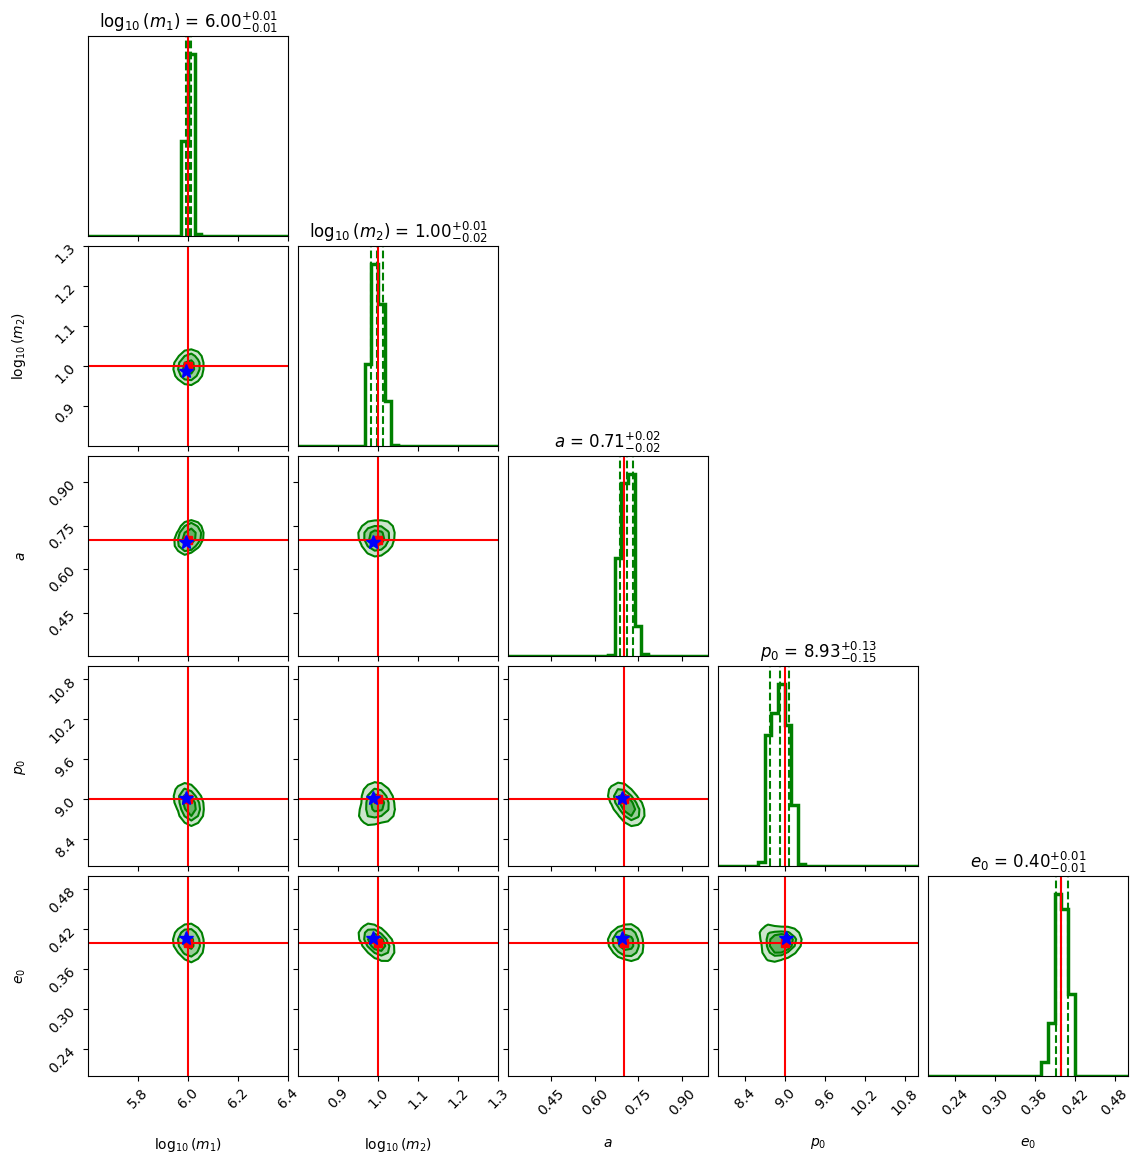

In [14]:
import corner
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$',r'$T$']
fig = corner.corner(
    samples,
    weights=weights,
    labels=labels,
    truths=param_true,
    truth_color='red',
    color='green',
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],
    smooth=True,
    bins=30,
    plot_datapoints=False,
    hist_kwargs={"density": True, 'linewidth': 2.5},
    linewidth=2.5,
    fill_contours=True,
    range = param_ranges
)

corner.overplot_points(fig, maxld_pt1.reshape(1, -1), 
                       color='blue', marker='*', ms=10, 
                       reverse=False)




In [15]:
np.sort(logden_list)

array([[19.33913965, 27.57959145, 27.84105889, ..., 93.97554043,
        94.06367585, 94.54835781]])

In [16]:
top10_idx = np.argsort(logden_list).flatten()[-10:][::-1]
top10_idx

array([2342, 3034, 2117, 2159, 2825, 4759, 1709, 2824, 4627, 1729])

In [17]:
top10_pts = prior_transform(proc_pt[0][top10_idx])
top10_pts

array([[5.99394189, 0.98819662, 0.69401447, 9.0204296 , 0.406847  ],
       [6.00299005, 0.99654651, 0.70975246, 8.93241812, 0.40118127],
       [5.99560042, 0.99310082, 0.69433182, 9.01709528, 0.40380858],
       [5.99595548, 0.99404031, 0.69455544, 9.01707234, 0.40333994],
       [6.00182201, 1.00031861, 0.70408865, 8.96163667, 0.39890366],
       [6.00069218, 0.99664597, 0.70417204, 8.96300976, 0.40131253],
       [5.99819084, 0.99729019, 0.69756476, 9.00007352, 0.40120791],
       [6.00032833, 0.99306009, 0.70591448, 8.95370095, 0.40344948],
       [6.01131981, 0.99849106, 0.72830392, 8.82709096, 0.399246  ],
       [5.99932035, 0.99911889, 0.69890111, 8.99271853, 0.40003614]])

In [18]:
ranges = [                                                                                                                                                                         
    (5.6, 6.4),                                                                                                                                                                    
    (0.8, 1.3),                                                                                                                                                                    
    (0.3, 0.99),                                                                                                                                                                   
    (8.0, 11.0),                                                                                                                                                                 
    (0.2, 0.5),
]       

In [19]:
labels = [r'$\log m_1$', r'$\log m_2$', r'$a$', r'$p_0$', r'$e_0$']                                                                                                        
true_params = np.array([6.0, 1.0, 0.7, 9.0, 0.4])
ndim = 5                                                                                                                                                                           
            

In [20]:
import matplotlib.pyplot as plt

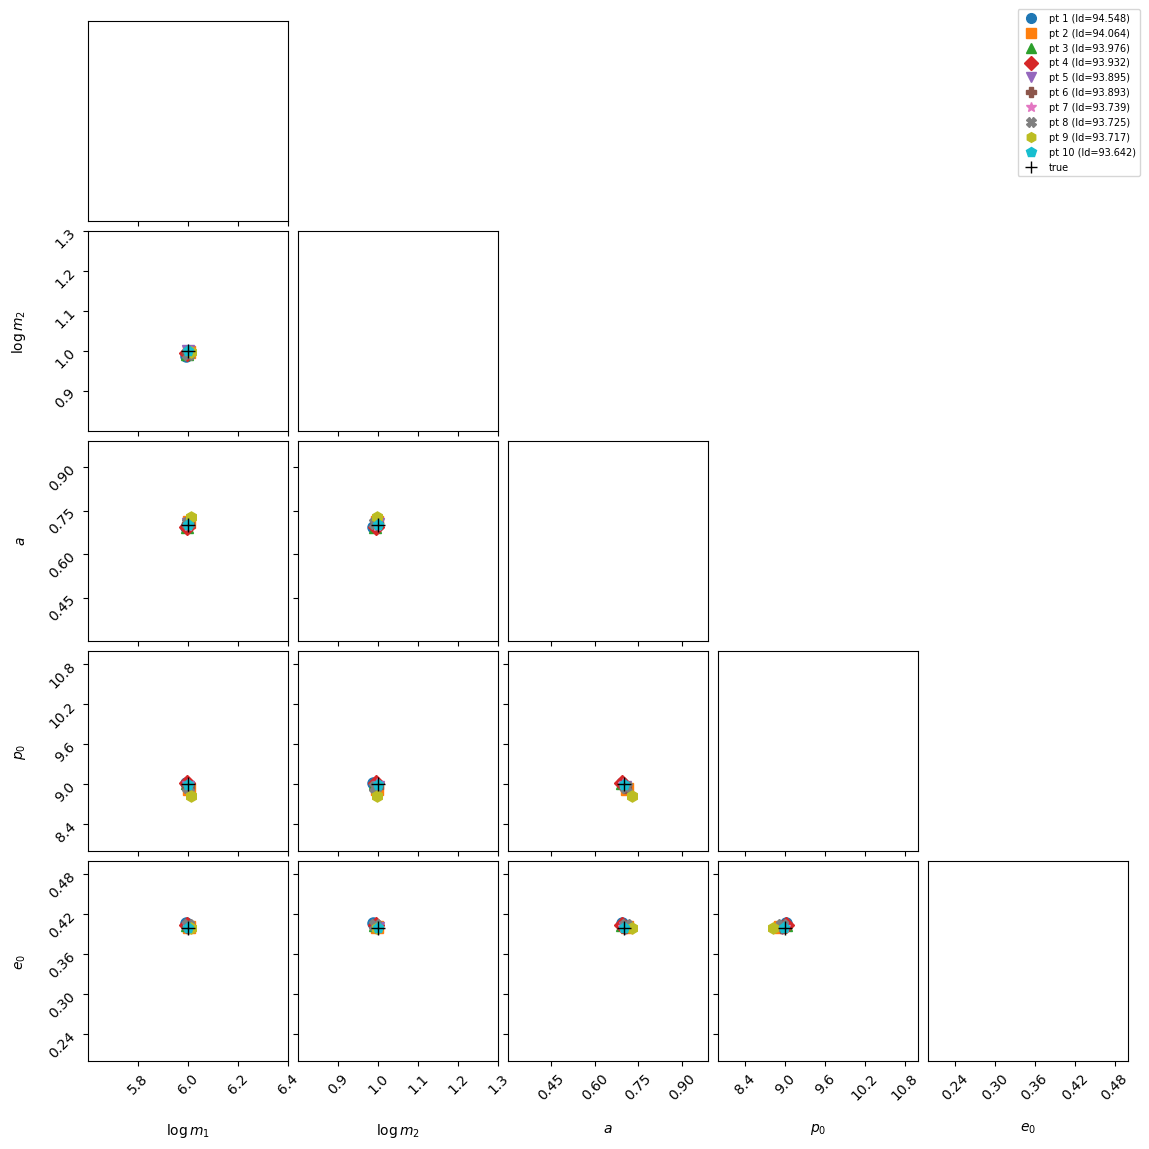

In [21]:
_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
markers_list = ['o', 's', '^', 'D', 'v', 'P', '*', 'X', 'h', 'p']

all_pts = np.vstack([top10_pts, [true_params]])
fig = corner.corner(all_pts, labels=labels, show_titles=False,
                    plot_datapoints=False, plot_density=False, plot_contours=False, ranges=ranges,
                    hist_kwargs=dict(alpha=0, lw=0))

for i, pt in enumerate(top10_pts):
    corner.overplot_points(fig, pt.reshape(1, -1), color=_cycle[i % len(_cycle)], marker=markers_list[i], ms=8)

corner.overplot_points(fig, np.array([true_params]), color='black', marker='+', ms=10)

# Re-enforce ranges
axes = np.array(fig.axes).reshape((ndim, ndim))
for row in range(ndim):
    for col in range(ndim):
        if col <= row:
            axes[row, col].set_xlim(ranges[col])
        if col < row:
            axes[row, col].set_ylim(ranges[row])

from matplotlib.lines import Line2D
ld_vals = np.concatenate(logden_list)[top10_idx]
handles = [Line2D([0],[0], color=_cycle[i % len(_cycle)], marker=markers_list[i], ls='', ms=7,
                label=f"pt {i+1} (ld={ld_vals[i]:.3f})")
            for i in range(10)]
handles.append(Line2D([0],[0], color='black', marker='+', ls='', ms=8, label='true'))
fig.legend(handles=handles, loc='upper right', bbox_to_anchor=(0.98, 0.98), fontsize=7)
plt.show()

In [22]:
w_norm = weights / weights.sum()
ess = 1.0 / np.sum(w_norm**2)
print(ess, f'{100*ess/len(weights)}%')

40.072743113748 0.80145486227496%


# connection plot

In [23]:
proc1_maxld_pt = maxld_pt1.copy()
proc1_maxld_pt

array([[5.99394189, 0.98819662, 0.69401447, 9.0204296 , 0.406847  ]])

In [24]:
# connect two highest logden pts

proc1_maxld_pt_1d = proc1_maxld_pt[0] 
true_pt = np.array(param_true)

# NOTE: connecting only till the true/target pt 
n_points = 50
t_values = np.linspace(0, 1, n_points)  # extend beyond each endpoint
line_points_proc1 = proc1_maxld_pt_1d[:, np.newaxis] + t_values * (true_pt - proc1_maxld_pt_1d)[:, np.newaxis]


In [25]:
logden_theory_proc1 = []
logden_theory_proc1.append(log_density(np.array(line_points_proc1).T))


In [26]:
logden_theory_proc1 = np.array(logden_theory_proc1).flatten()


In [27]:
logden_theory_proc1

array([9.45483578, 9.4013641 , 9.02574999, 9.17749834, 9.25683003,
       9.35100763, 8.91373599, 9.12449439, 9.20771502, 9.2237834 ,
       8.91818688, 9.02130296, 9.04122216, 8.67274759, 8.67822625,
       8.68819909, 8.58974117, 8.53489304, 8.53771345, 8.6198915 ,
       8.57386568, 8.52708083, 8.59278897, 8.60310371, 8.55936626,
       8.56499842, 8.54215174, 8.53870993, 8.57001814, 8.57319609,
       8.61636728, 8.5794806 , 8.64014314, 8.5844794 , 8.63247367,
       8.57250346, 8.42277569, 8.49279103, 8.43414784, 8.47512653,
       8.34915423, 8.55493821, 8.36959619, 8.62177102, 8.31755889,
       8.58161176, 8.2851551 , 8.66051624, 8.75921545, 8.61286619])

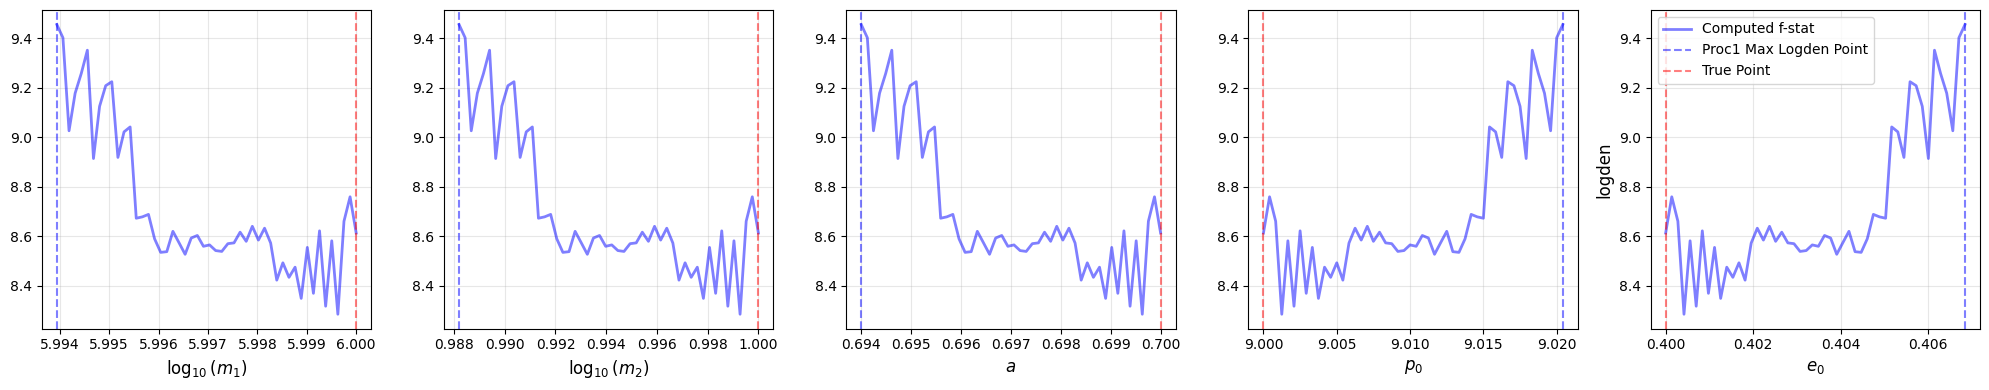

In [28]:
import matplotlib.pyplot as plt
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$', r'$T$']
plt.ylabel('logden', fontsize=12)
for dim in range(5):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], logden_theory_proc1, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed f-stat')


    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True Point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('logden', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()
